# Previne Brasil: os indicadores da atenção primária, município a município

**Pergunta que este notebook responde:** como estão os municípios do meu estado
nos indicadores de desempenho da Atenção Primária — e onde a diferença entre
eles é maior?

**Fonte:** SISAB, pela API de dados abertos do Ministério da Saúde
(`apidadosabertos.saude.gov.br`). São os indicadores que compunham o
cofinanciamento federal da APS (Portaria nº 2.979/2019).
**Tempo estimado:** 3 a 6 minutos.

> **Este notebook não usa o FTP do DATASUS.** A atenção primária não está lá.
> Ela vem de uma API REST — não há `state=`, não há `.parquet`, não há `group`.
> E, como você vai ver no passo 2, a paginação dessa API tem um defeito que faz
> a coleta ingênua perder um terço dos registros **sem avisar**.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()   # obrigatório: a PySUS é assíncrona por dentro
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

Troque a sigla do estado e rode tudo de novo.

In [3]:
UF = "PR"    # sigla do estado

## Passo 1 — De onde vêm estes dados

A PySUS tem uma função `atencao_primaria()`, mas **ela devolve vazio**: há um
erro de chave interno na biblioteca (testado nas versões 2.10.3 e 2.10.4). O
que funciona é o utilitário de paginação da própria PySUS, apontado direto para
o endpoint do SISAB.

In [4]:
import asyncio
import httpx
import pandas as pd
from pysus.api.saude.rest import iter_rows

BASE = "https://apidadosabertos.saude.gov.br"
ENDPOINT = "/atencao-primaria/indicador-desempenho-programa-previne-brasil"
CHAVE = ["codigo_municipio", "competencia", "codigo_tipo_indicador", "visao_equipe"]

async def coletar_por_offset(uf):
    linhas = []
    async with httpx.AsyncClient(timeout=120) as cliente:
        async for linha in iter_rows(cliente, ENDPOINT,
                                     params={"uf": uf}, page_size=1000):
            linhas.append(linha)
    return pd.DataFrame(linhas)

primeira = asyncio.run(coletar_por_offset(UF))
print(f"{len(primeira):,} linhas recebidas para {UF}")
print(f"Colunas: {list(primeira.columns)}")

21,546 linhas recebidas para PR
Colunas: ['uf', 'municipio', 'codigo_tipo_indicador', 'numerador', 'denominador_utilizador', 'percentual_quadrimestre', 'visao_equipe', 'denominador_identificado', 'denominador_estimado', 'cadastro', 'base_externa', 'populacao', 'quadrimestre', 'codigo_municipio', 'competencia', 'percentual']


## Passo 2 — A armadilha: a mesma consulta, duas respostas diferentes

Parece que deu certo. Mas repita a coleta e compare **quais** registros vieram.

A API pagina por deslocamento de linha (`offset`) sobre um resultado que não
tem ordenação garantida. Entre uma página e a próxima as linhas se movem: umas
aparecem duas vezes, outras nunca aparecem. O total sempre bate — o conteúdo,
não.

In [5]:
segunda = asyncio.run(coletar_por_offset(UF))

def chaves(df):
    return set(map(tuple, df.drop_duplicates()[CHAVE].astype(str).values))

k1, k2 = chaves(primeira), chaves(segunda)

print(f"coleta 1: {len(primeira):,} linhas → {len(k1):,} registros distintos")
print(f"coleta 2: {len(segunda):,} linhas → {len(k2):,} registros distintos")
print(f"\nO mesmo número de linhas nas duas: {len(primeira) == len(segunda)}")
print(f"Os mesmos registros?                {k1 == k2}")
print(f"Registros que só uma das coletas viu: {len(k1 ^ k2):,}")
print(f"\nCada passada repete linhas para preencher o lugar das que perdeu:")
print(f"  coleta 1 repetiu {len(primeira) - len(k1):,} linhas "
      f"({(len(primeira) - len(k1)) / len(primeira) * 100:.0f}%)")

coleta 1: 21,546 linhas → 14,528 registros distintos
coleta 2: 21,546 linhas → 13,677 registros distintos
O mesmo número de linhas nas duas: True
Os mesmos registros?                False
Registros que só uma das coletas viu: 9,777
Cada passada repete linhas para preencher o lugar das que perdeu:
  coleta 1 repetiu 7,018 linhas (33%)


## Passo 3 — A coleta que funciona: um município por vez

A saída é não usar `offset`. O endpoint aceita `codigo_municipio`, e um
município cabe folgado numa resposta só — então cada pedido é uma página única,
sem deslocamento e sem instabilidade.

São centenas de pedidos pequenos em vez de dezenas de grandes; com oito em
paralelo, o estado inteiro leva cerca de quinze segundos.

In [6]:
async def um_municipio(cliente, codigo):
    resposta = await cliente.get(
        BASE + ENDPOINT,
        params={"codigo_municipio": codigo, "limit": 1000, "offset": 0})
    resposta.raise_for_status()
    corpo = resposta.json()
    return next((v for v in corpo.values() if isinstance(v, list)), [])

async def coletar_completo(codigos, paralelas=8):
    limite = asyncio.Semaphore(paralelas)

    async def tarefa(cliente, codigo):
        async with limite:
            return await um_municipio(cliente, codigo)

    async with httpx.AsyncClient(timeout=120) as cliente:
        partes = await asyncio.gather(*[tarefa(cliente, c) for c in codigos])
    return pd.DataFrame([linha for parte in partes for linha in parte])

# os códigos podem sair da coleta anterior: ela perde registros, mas não municípios
municipios = sorted(set(primeira["codigo_municipio"]) | set(segunda["codigo_municipio"]))
dados = asyncio.run(coletar_completo(municipios))

NUMERICAS = ["numerador", "denominador_utilizador", "denominador_identificado",
             "denominador_estimado", "percentual", "percentual_quadrimestre",
             "cadastro", "populacao", "base_externa"]
for coluna in NUMERICAS:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

print(f"{len(municipios)} municípios → {len(dados):,} registros")
print(f"Linhas repetidas: {len(dados) - len(dados.drop_duplicates()):,}")
print(f"Registros por município: "
      f"{dados.groupby('codigo_municipio').size().unique()}")
print(f"\nGanho sobre a coleta por offset: "
      f"{len(dados) - len(k1):,} registros que ela não tinha trazido.")

399 municípios → 21,546 registros
Linhas repetidas: 0
Registros por município: [54]
Ganho sobre a coleta por offset: 7,018 registros que ela não tinha trazido.


Cada município devolve exatamente o mesmo número de registros: **3 competências
× 6 indicadores × 3 visões**. A base é completa e retangular — o que parecia
"município que não reporta tal indicador" era, o tempo todo, registro perdido
na paginação.

In [7]:
print("Competências:", sorted(dados["competencia"].unique()))
print("Indicadores: ", sorted(dados["codigo_tipo_indicador"].unique()))
print("Visões:      ", sorted(dados["visao_equipe"].unique()))
print(f"\n3 × 6 × 3 = {3*6*3} registros por município ✓")

Competências: [np.int64(202404), np.int64(202408), np.int64(202412)]
Indicadores:  [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(70)]
Visões:       ['geral', 'homologadas', 'validas']
3 × 6 × 3 = 54 registros por município ✓


## Passo 4 — Qual coluna é o resultado?

A tabela tem duas colunas parecidas, e a de nome mais óbvio **não é** o
resultado do indicador:

| Coluna | O que é de verdade |
|---|---|
| `percentual_quadrimestre` | **o resultado** — numerador ÷ denominador utilizado |
| `percentual` | **cobertura de cadastro** — pessoas identificadas ÷ estimativa do IBGE |

É por isso que `percentual` passa de 100 em metade das linhas: quando a equipe
cadastra mais gente do que a estimativa previa, a razão ultrapassa 100%. É
informação valiosa — só não é desempenho.

In [8]:
geral = dados[dados["visao_equipe"] == "geral"].copy()

def confere(formula, coluna):
    return ((formula - geral[coluna]).abs() < 1.5).mean() * 100

resultado = 100 * geral["numerador"] / geral["denominador_utilizador"].where(lambda s: s != 0)
cobertura = 100 * geral["denominador_identificado"] / geral["denominador_estimado"].where(lambda s: s != 0)

print(f"percentual_quadrimestre = 100 × numerador ÷ den. utilizador"
      f"   → confere em {confere(resultado, 'percentual_quadrimestre'):.1f}% das linhas")
print(f"percentual              = 100 × den. identificado ÷ den. estimado"
      f" → confere em {confere(cobertura, 'percentual'):.1f}% das linhas")
print(f"\n`percentual` passa de 100 em "
      f"{(geral['percentual'] > 100).mean() * 100:.0f}% das linhas.")

percentual_quadrimestre = 100 × numerador ÷ den. utilizador   → confere em 100.0% das linhas
percentual              = 100 × den. identificado ÷ den. estimado → confere em 100.0% das linhas
`percentual` passa de 100 em 50% das linhas.


## Passo 5 — Que indicador é cada código?

A API **não documenta** os códigos `10`, `20`, `30`… Não há tabela no swagger
nem no pacote da PySUS. Seguindo a regra da casa — nunca adivinhar código —
identificamos pelo comportamento do denominador.

O Previne Brasil tem sete indicadores: três de gestante (pré-natal com seis
consultas, exames de sífilis e HIV, atendimento odontológico), um de
citopatológico, um de vacinação infantil, um de hipertensão e um de diabetes.
Os três de gestante medem **a mesma população** — então têm de compartilhar
exatamente o mesmo denominador.

In [9]:
ultima = geral[geral["competencia"] == geral["competencia"].max()]

denominadores = ultima.pivot_table(index="codigo_municipio",
                                   columns="codigo_tipo_indicador",
                                   values="denominador_utilizador",
                                   aggfunc="first")

codigos = list(denominadores.columns)
print("Fração de municípios em que dois códigos têm o MESMO denominador:\n")
print("      " + "".join(f"{c:>7}" for c in codigos))
for a in codigos:
    linha = f"  {a:>3} "
    for b in codigos:
        par = denominadores[[a, b]].dropna()
        igual = 1.0 if a == b else (par.iloc[:, 0] == par.iloc[:, 1]).mean()
        linha += f"{igual:>7.2f}"
    print(linha)

Fração de municípios em que dois códigos têm o MESMO denominador:
           10     20     30     40     50     70
   10    1.00   1.00   1.00   0.00   0.20   0.00
   20    1.00   1.00   1.00   0.00   0.20   0.00
   30    1.00   1.00   1.00   0.00   0.20   0.00
   40    0.00   0.00   0.00   1.00   0.00   0.00
   50    0.20   0.20   0.20   0.00   1.00   0.00
   70    0.00   0.00   0.00   0.00   0.00   1.00


O bloco de `1.00` isola os três indicadores que dividem a mesma população: são
os de gestante. O tamanho do denominador separa o resto — citopatológico cobre
mulheres de 25 a 64 anos (milhares por município), vacinação acompanha as
crianças que fazem 1 ano (dezenas), diabetes fica no meio.

> **Falta um.** O conjunto oficial tem sete indicadores; a API entrega seis.
> Antes de publicar qualquer análise, confirme o significado de cada código no
> painel oficial do SISAB — este notebook mostra o que os dados provam, não
> inventa o rótulo que falta.

In [10]:
tamanhos = (ultima.groupby("codigo_tipo_indicador")
            .agg(den_mediano=("denominador_utilizador", "median"),
                 resultado_mediano=("percentual_quadrimestre", "median"),
                 municipios=("codigo_municipio", "nunique"))
            .sort_values("den_mediano"))
tamanhos.index.name = "código"
tamanhos

,den_mediano,resultado_mediano,municipios
código,,,
10,36.0,64.0,399
20,36.0,75.0,399
30,36.0,67.0,399
50,37.0,93.0,399
70,915.0,27.0,399
40,2733.0,35.0,399


## Passo 6 — As três visões da mesma equipe

Cada resultado vem em três versões — `geral`, `homologadas` e `validas` — que
mudam quais equipes entram na conta. Divergem em cerca de um caso em oito.
Escolha uma e diga qual usou.

In [11]:
comparacao = (dados[dados["competencia"] == dados["competencia"].max()]
              .pivot_table(index=["codigo_municipio", "codigo_tipo_indicador"],
                           columns="visao_equipe",
                           values="percentual_quadrimestre"))

diferenca = (comparacao["geral"] - comparacao["validas"]).abs()
print(f"'geral' e 'validas' coincidem em "
      f"{(comparacao['geral'] == comparacao['validas']).mean() * 100:.1f}% dos casos")
print(f"Quando divergem: diferença média de {diferenca[diferenca > 0].mean():.1f} "
      f"pontos, máxima de {diferenca.max():.0f}\n")
comparacao.describe().round(1)

'geral' e 'validas' coincidem em 91.7% dos casos
Quando divergem: diferença média de 4.0 pontos, máxima de 48


visao_equipe,geral,homologadas,validas
count,2394.0,2394.0,2394.0
mean,59.5,59.4,59.4
std,27.2,27.3,27.3
min,0.0,0.0,0.0
25%,37.0,37.0,37.0
50%,60.0,60.0,60.0
75%,83.0,83.0,83.0
max,100.0,100.0,100.0


## Passo 7 — O desempenho do estado, por indicador

Usamos a **mediana** entre municípios, e não a média: quando a pergunta é "como
está a rede", um município grande não deve pesar mais que um pequeno.

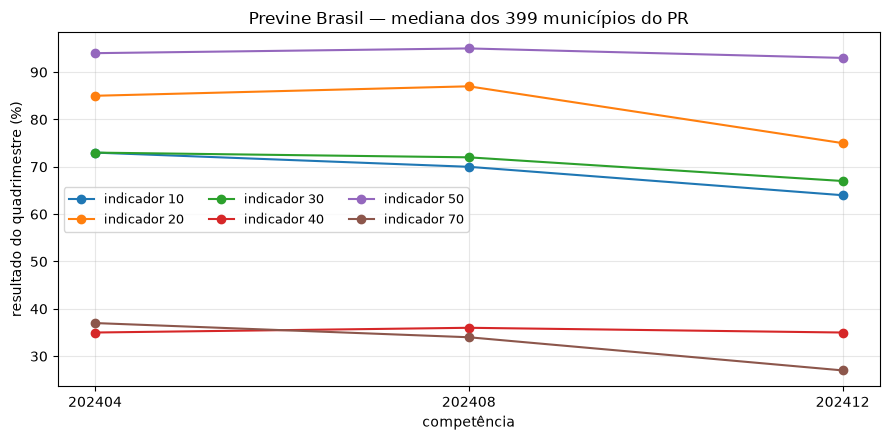

codigo_tipo_indicador,10,20,30,40,50,70
competencia,,,,,,
202404,73.0,85.0,73.0,35.0,94.0,37.0
202408,70.0,87.0,72.0,36.0,95.0,34.0
202412,64.0,75.0,67.0,35.0,93.0,27.0


In [12]:
import matplotlib.pyplot as plt

serie = (geral.groupby(["competencia", "codigo_tipo_indicador"])
         ["percentual_quadrimestre"].median().unstack())

fig, ax = plt.subplots(figsize=(9, 4.5))
for codigo in serie.columns:
    ax.plot(serie.index.astype(str), serie[codigo], marker="o",
            label=f"indicador {codigo}")
ax.set_title(f"Previne Brasil — mediana dos {geral['codigo_municipio'].nunique()} "
             f"municípios do {UF}")
ax.set_ylabel("resultado do quadrimestre (%)")
ax.set_xlabel("competência")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

serie.round(1)

## Passo 8 — Onde a diferença entre municípios é maior

A mediana esconde a desigualdade. Aqui está, na competência mais recente, a
distância entre os municípios que vão bem e os que vão mal em cada indicador —
que costuma ser onde a gestão estadual precisa agir.

In [13]:
espalhamento = (ultima.groupby("codigo_tipo_indicador")["percentual_quadrimestre"]
                .describe(percentiles=[0.1, 0.5, 0.9])
                [["10%", "50%", "90%", "count"]].round(1))
espalhamento["distância 10%→90%"] = (espalhamento["90%"] - espalhamento["10%"]).round(1)
espalhamento.index.name = "código"
print(f"Competência {ultima['competencia'].max()} — "
      f"todos os {int(espalhamento['count'].max())} municípios em cada linha\n")
espalhamento

Competência 202412 — todos os 399 municípios em cada linha


,10%,50%,90%,count,distância 10%→90%
código,,,,,
10,40.0,64.0,87.0,399.0,47.0
20,44.0,75.0,100.0,399.0,56.0
30,35.0,67.0,94.0,399.0,59.0
40,22.0,35.0,52.0,399.0,30.0
50,67.0,93.0,100.0,399.0,33.0
70,7.0,27.0,61.0,399.0,54.0


## Passo 9 — Cadastrar mais anda junto com desempenho melhor?

Agora as duas colunas do passo 4 trabalham juntas: `percentual` é o quanto a
equipe cadastrou da população estimada; `percentual_quadrimestre` é o
desempenho. Cadastrar mais aumenta o denominador, então poderia até piorar o
indicador.

> **Cuidado ao ler.** As duas colunas nascem dos mesmos denominadores, então
> parte da associação pode ser mecânica. Isto descreve um padrão; não prova que
> cadastrar causa desempenho.

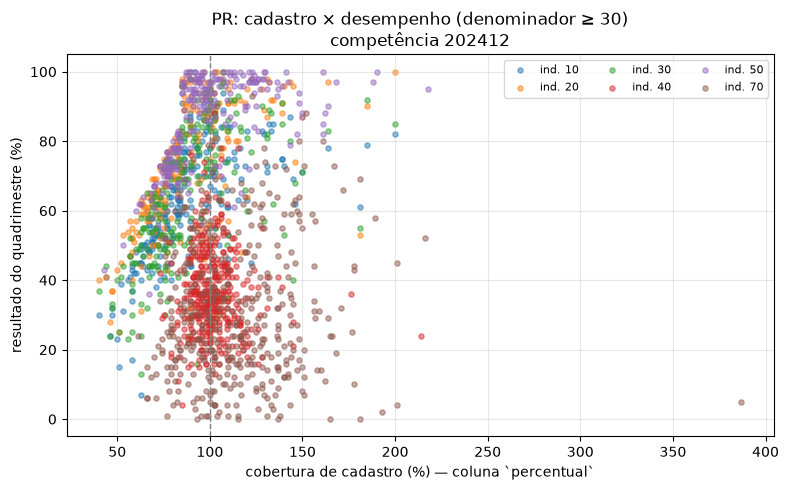

,correlação cadastro × resultado
codigo_tipo_indicador,
10,0.64
20,0.62
30,0.51
40,-0.03
50,0.56
70,0.06


In [14]:
foco = ultima[ultima["denominador_utilizador"] >= 30]   # evita número pequeno

# O grafico anterior mostrava a serie inteira, com a competencia no eixo x.
# Este mostra UM quadrimestre so — entao ele precisa dizer qual, ou a figura
# solta numa apresentacao vira um retrato sem data.
COMPETENCIA = str(ultima["competencia"].iloc[0])

fig, ax = plt.subplots(figsize=(8, 5))
for codigo in sorted(foco["codigo_tipo_indicador"].unique()):
    sub = foco[foco["codigo_tipo_indicador"] == codigo]
    ax.scatter(sub["percentual"], sub["percentual_quadrimestre"],
               s=14, alpha=0.5, label=f"ind. {codigo}")
ax.axvline(100, color="grey", lw=1, ls="--")
ax.set_xlabel("cobertura de cadastro (%) — coluna `percentual`")
ax.set_ylabel("resultado do quadrimestre (%)")
ax.set_title(f"{UF}: cadastro × desempenho (denominador ≥ 30)"
             f"\ncompetência {COMPETENCIA}", fontsize=12)
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

correlacoes = (foco.groupby("codigo_tipo_indicador")
               .apply(lambda s: s["percentual"].corr(s["percentual_quadrimestre"]),
                      include_groups=False)
               .round(2))
correlacoes.name = "correlação cadastro × resultado"
correlacoes.to_frame()

## O que este notebook não responde

- **Falta um dos sete indicadores.** A API entrega seis códigos. Não invente o
  que falta.
- **`percentual` não é desempenho.** Se você levar só uma lição daqui, leve
  esta: metade das linhas passa de 100 e não significa meta superada.
- **Nunca colete esta API por `offset`.** O passo 2 mostra o preço: um terço
  dos registros some em silêncio, e o total continua batendo. Colete por
  município.
- **A API sai do ar.** Durante a construção deste exemplo ela ficou mais de uma
  hora indisponível (erro 502). Se acontecer, tente mais tarde — não é o seu
  código.
- **Números pequenos enganam.** Um município com 8 gestantes salta de 50% para
  62% com um único atendimento. O passo 9 corta denominadores abaixo de 30 por
  isso.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [15]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

conferir(1, "Vieram indicadores", len(dados) > 0, f"{len(dados):,} linhas")
conferir(2, "O recorte é do estado pedido",
         set(dados["sg_uf"].dropna().unique()) <= {UF} if "sg_uf" in dados else True)

# A armadilha que documentamos: 'percentual' NAO e o resultado do indicador,
# e cobertura de cadastro — por isso passa de 100 em boa parte das linhas.
if "percentual" in dados.columns and "percentual_quadrimestre" in dados.columns:
    acima = (pd.to_numeric(dados["percentual"], errors="coerce") > 100).mean()
    conferir(3, "A coluna 'percentual' passa de 100 (é cobertura, não resultado)",
             acima > 0.1, f"{acima * 100:.0f}% das linhas")
    q = pd.to_numeric(dados["percentual_quadrimestre"], errors="coerce").dropna()
    conferir(4, "O indicador de verdade fica entre 0 e 100",
             bool(((q >= 0) & (q <= 100)).all()),
             f"de {q.min():.1f} a {q.max():.1f}")

conferir(5, "O recorte do gráfico exclui denominador pequeno",
         bool((foco["denominador_utilizador"] >= 30).all()),
         f"{len(foco)} municípios")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

Verificações
1. Vieram indicadores — 21,546 linhas: confere
2. O recorte é do estado pedido: confere
3. A coluna 'percentual' passa de 100 (é cobertura, não resultado) — 51% das linhas: confere
4. O indicador de verdade fica entre 0 e 100 — de 0.0 a 100.0: confere
5. O recorte do gráfico exclui denominador pequeno — 1711 municípios: confere
Tudo confere.
